| Experimento | Descripción |
|-------------|-------------|
| **EXP1** | Degradación de la señal: ¿cómo responde la entropía de atención al ruido en la entrada? |
| **EXP2** | Sensibilidad semántica: cabezas que más distinguen texto coherente de ruido i.i.d. |
| **EXP3** | Diferenciación de estilo: cabezas que más distinguen modo wiki de modo poem |

## Requisitos
```bash
pip install -e ".[dev]"   # desde la raíz de attnspectra/
```


## 1. Imports y configuración

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
# Añadir experiments/ al path para importar gpt_model
sys.path.insert(0, str(Path.cwd().parent / "experiments"))

import re
import numpy as np
import matplotlib.pyplot as plt
import torch
from tokenizers import Tokenizer

import attnspectra as aspec
from attnspectra import (
    CaptureConfig, CustomGPTAdapter,
    compute_head_metrics, stack_metric, top_sensitive_heads,
    make_variants, plot_attention_matrix, plot_attention_matrix_interactive,
    heatmap_delta, heatmap_metric,
    plot_delta_lines_by_condition, plot_metric_by_layer,
    save_run, save_metrics, load_run, load_metrics,
    set_seed,
)
from models.gpt_model import GPT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("attnspectra version:", aspec.__version__)
print("Device:", device)

attnspectra version: 0.1.2
Device: cuda


## 2. Carga del modelo

In [2]:
CKPT_PATH = "../checkpoints/best.pt"

ckpt      = torch.load(CKPT_PATH, map_location=device, weights_only=False)
tokenizer = Tokenizer.from_file(str(Path.cwd().parent /"tokenizer_mix_es" / "tokenizer.json"))

sid         = ckpt["special_ids"]
pad_id      = sid["pad_id"]
bos_id      = sid["bos_id"]
eos_id      = sid["eos_id"]
wiki_tok_id = sid["wiki_tok_id"]
poem_tok_id = sid["poem_tok_id"]
sep_id      = sid["sep_id"]

cfg   = ckpt["config"]
model = GPT(**cfg).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()
torch.set_grad_enabled(False)

print(f"Modelo cargado | opt_step={ckpt['opt_step']}")

Modelo cargado | opt_step=25000


## 3. Adapter y configuración de captura

In [3]:
adapter = CustomGPTAdapter(
    model=model,
    tokenizer=tokenizer,
    n_layers=cfg["n_layers"],
    n_heads=cfg["n_heads"],
    d_model=cfg["d_model"],
    model_name="custom-gpt-es",
    device=device,
)

capture_config = CaptureConfig(
    capture_attn_pre=True,
    capture_scores=False,
    target_layers=None,   # None = todas las capas
)

PREFIX_LEN  = 3   # <bos> <style> <sep>
VOCAB_SIZE  = cfg["vocab_size"]
STYLE_WIKI  = 0
STYLE_POEM  = 1

def build_ids(text: str, style_idx: int, max_len: int = 256) -> list[int]:
    """Construye la secuencia de ids con el prefijo de estilo correcto."""
    style_token = wiki_tok_id if style_idx == STYLE_WIKI else poem_tok_id
    prefix  = [bos_id, style_token, sep_id]
    content = tokenizer.encode(text.replace("\n", " <nl> ")).ids
    ids = prefix + content
    if max_len and len(ids) > max_len:
        ids = ids[:PREFIX_LEN] + ids[-(max_len - PREFIX_LEN):]
    return ids

def capture_text(text: str, style_idx: int, max_len: int = 256):
    """Captura atención para un texto y devuelve (CapturedRun, HeadMetrics)."""
    ids        = build_ids(text, style_idx, max_len)
    input_ids  = torch.tensor([ids], dtype=torch.long)
    run        = adapter.capture_from_ids(input_ids, capture_config, style_idx=style_idx)
    metrics    = compute_head_metrics(run)
    return run, metrics

print("Adapter OK:", adapter.model_info)

Adapter OK: ModelInfo(name='custom-gpt-es', architecture='decoder', n_layers=8, n_heads=8, d_model=512, extra={})


### Visualización de una matriz de atención

seq_len=14 | tokens: ['', '', '', ' La', ' pa', 'ella', ' es', ' el', ' plato', ' más']


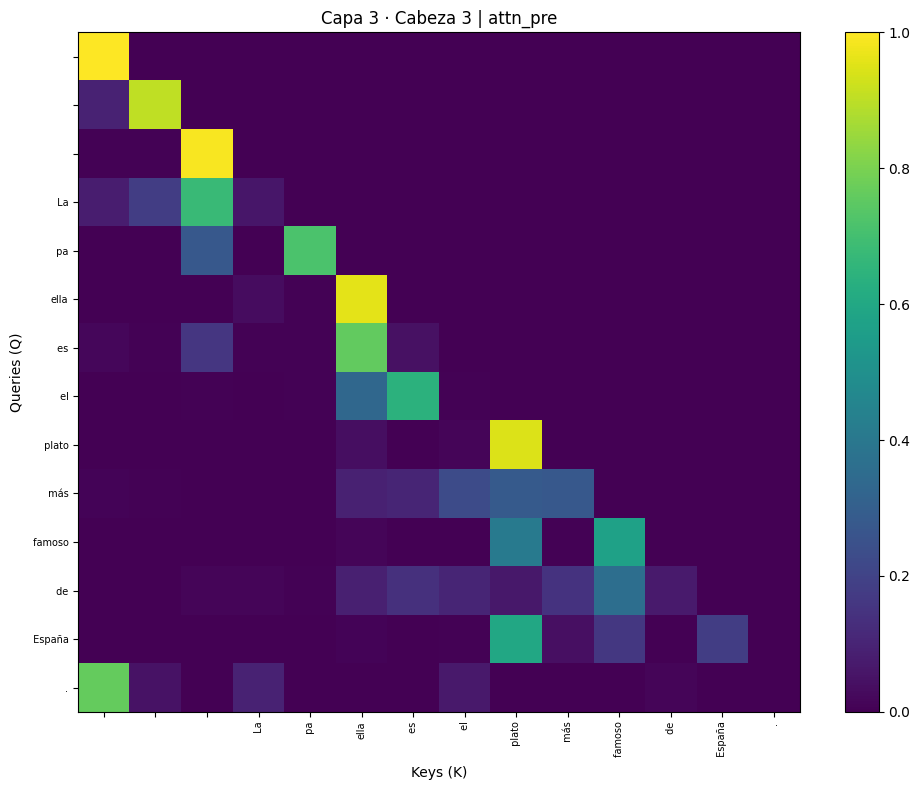

In [18]:
set_seed(42)

run_test, metrics_test = capture_text(
    "La paella es el plato más famoso de España.",
    style_idx=STYLE_WIKI
)

print(f"seq_len={run_test.seq_len} | tokens: {run_test.token_strs[:10]}")

# Mostrar la capa 3, cabeza 3
A = run_test.get_attention(layer=3, head=3)
fig = plot_attention_matrix(A, run_test.token_strs, max_tokens=40,
                             title="Capa 3 · Cabeza 3 | attn_pre")

plt.savefig("resultados_analisis/matriz_atencion.png", dpi=120, bbox_inches="tight")
plt.show()

### Visualización interactiva de todas las matrices de atención por capa y cabeza

In [19]:
fig = plot_attention_matrix_interactive(run_test)

## EXP1 — Degradación de la señal

**Hipótesis**: la entropía de atención aumenta cuando se introduce ruido en la entrada,
porque las cabezas no pueden encontrar patrones y distribuyen la atención de forma más uniforme.

**Variantes de degradación**:
- `clean`: texto original
- `shuffle`: tokens de contenido barajados aleatoriamente
- `replace_10/30/50%`: fracción de tokens reemplazados por ids aleatorios
- `random_iid`: todo el contenido reemplazado por ids uniformes i.i.d.


In [6]:
TEXTS_EXP1_EXP2 = [
    "La fotosíntesis es el proceso por el cual las plantas convierten la luz solar en energía química.",
    "Madrid es la capital de España y uno de los principales centros culturales y económicos del país.",
    "El aprendizaje automático utiliza datos para construir modelos que generalizan a ejemplos no vistos.",
    "La historia de España abarca múltiples periodos, desde la Antigüedad hasta la democracia contemporánea.",
    "Los océanos regulan el clima global mediante corrientes marinas, intercambio de calor y ciclos biogeoquímicos.",
    "El sistema solar está formado por el Sol y los cuerpos celestes que orbitan a su alrededor.",
    "La Revolución Industrial transformó las estructuras económicas y sociales de Europa durante el siglo XIX.",
    "El ADN contiene la información genética necesaria para el desarrollo y funcionamiento de los organismos vivos.",
    "La economía de mercado se basa en la oferta y la demanda como mecanismos de asignación de recursos.",
    "El teorema de Pitágoras establece una relación entre los lados de un triángulo rectángulo.",
    "La arquitectura gótica se caracteriza por el uso de arcos apuntados y grandes vidrieras de colores.",
    "La Unión Europea es una organización política y económica integrada por veintisiete estados miembros.",
    "El cerebro humano contiene aproximadamente ochenta y seis mil millones de neuronas interconectadas.",
    "La energía solar es una fuente renovable obtenida a partir de la radiación emitida por el Sol.",
    "El idioma español es la segunda lengua más hablada del mundo por número de hablantes nativos.",
    "La teoría de la relatividad especial fue formulada por Albert Einstein en el año mil novecientos cinco.",
    "Los volcanes son estructuras geológicas por las que emergen magma, gases y ceniza desde el interior de la Tierra.",
    "La democracia representativa es un sistema de gobierno en el que los ciudadanos eligen a sus representantes.",
    "El comercio internacional permite a los países especializarse en la producción de bienes con ventaja comparativa.",
    "Las matemáticas son una disciplina que estudia las relaciones entre cantidades, estructuras y patrones abstractos.",
]

set_seed(123)
MAX_LEN   = 256
T_FIXED   = None  # se calcula como el mínimo entre textos

# Calcular T_fixed
all_ids = [build_ids(t, STYLE_WIKI, MAX_LEN) for t in TEXTS_EXP1_EXP2]
T_FIXED = min(len(ids) for ids in all_ids)
print(f"T_fixed = {T_FIXED} tokens")

per_cond: dict[str, list] = {c: [] for c in
    ["clean","shuffle","replace_10%","replace_30%","replace_50%","random_iid"]}

for t, base_ids in zip(TEXTS_EXP1_EXP2, all_ids):
    # Recortar a T_fixed
    trimmed = base_ids[:PREFIX_LEN] + base_ids[-(T_FIXED - PREFIX_LEN):]
    variants = make_variants(trimmed, vocab_size=VOCAB_SIZE,
                             prefix_len=PREFIX_LEN, seed=123)
    for cond_name, vid in variants.items():
        vid_t = torch.tensor([vid], dtype=torch.long)
        vrun  = adapter.capture_from_ids(vid_t, capture_config, style_idx=STYLE_WIKI)
        per_cond[cond_name].append(compute_head_metrics(vrun))

T_fixed = 18 tokens


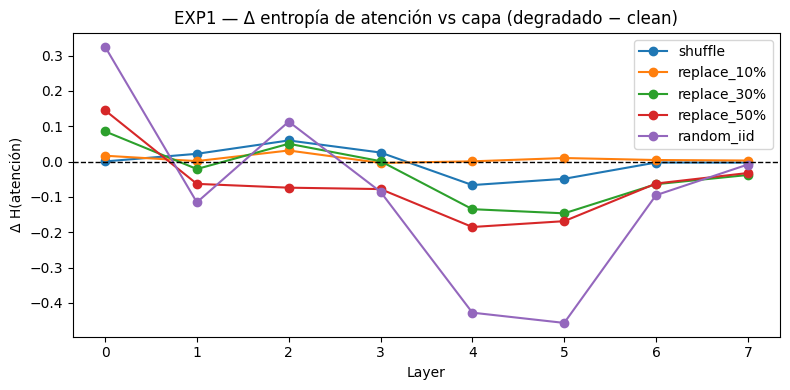

In [7]:
#  Gráfico: Δ entropía vs capa  ─
fig = plot_delta_lines_by_condition(
    per_cond,
    metric_key="A_attn_entropy",
    base="clean",
    title="EXP1 — Δ entropía de atención vs capa (degradado − clean)",
    ylabel="Δ H(atención)",
)
plt.savefig("resultados_analisis/exp1_entropia.png", dpi=120, bbox_inches="tight")
plt.show()

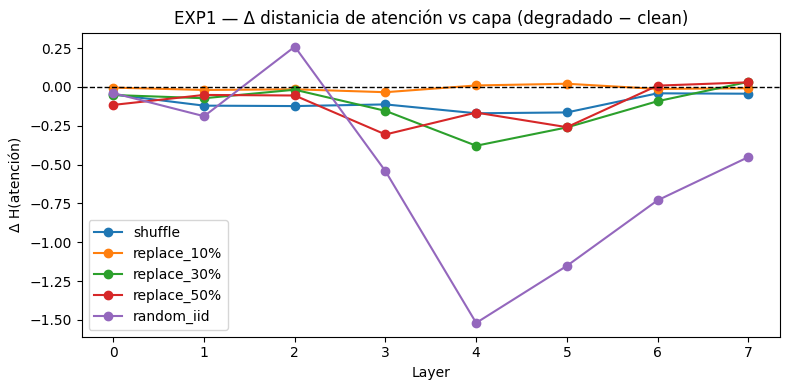

In [8]:
#  Gráfico: Δ distancia de atención vs capa  ─
fig = plot_delta_lines_by_condition(
    per_cond,
    metric_key="A_attn_distance",
    base="clean",
    title="EXP1 — Δ distanicia de atención vs capa (degradado − clean)",
    ylabel="Δ H(atención)",
)
plt.savefig("resultados_analisis/exp1_distancia_atencion.png", dpi=120, bbox_inches="tight")
plt.show()

## EXP2 — Sensibilidad semántica: coherente vs. ruido i.i.d.

**Hipótesis**: existe un subconjunto de cabezas que son especialmente sensibles a la
coherencia semántica de la entrada. Estas cabezas tendrán entropías significativamente
distintas entre texto coherente y ruido i.i.d.


In [9]:
set_seed(123)

sense_metrics, rand_metrics = [], []
for t in TEXTS_EXP1_EXP2:
    ids_sense = build_ids(t, STYLE_WIKI, MAX_LEN)
    ids_rand  = make_variants(ids_sense, vocab_size=VOCAB_SIZE,
                               prefix_len=PREFIX_LEN, seed=123)["random_iid"]

    r_s, m_s = capture_text(t, STYLE_WIKI, MAX_LEN)
    r_r = adapter.capture_from_ids(
        torch.tensor([ids_rand], dtype=torch.long),
        capture_config, style_idx=STYLE_WIKI
    )
    m_r = compute_head_metrics(r_r)

    sense_metrics.append(m_s)
    rand_metrics.append(m_r)

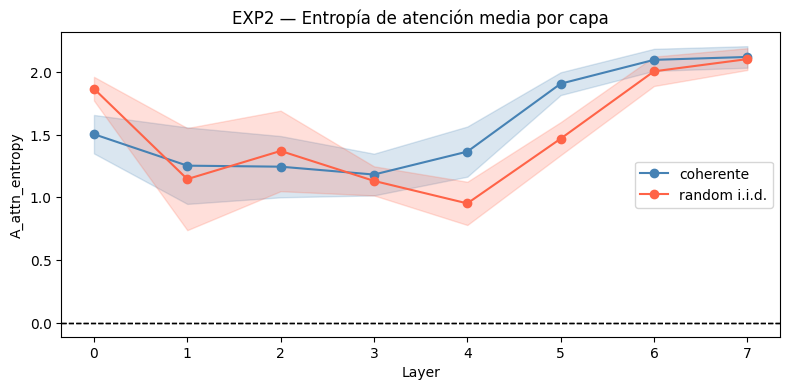

In [10]:
#  Comparación por capa  
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric_by_layer(sense_metrics, "A_attn_entropy", label="coherente",
                      color="steelblue",  ax=ax)
plot_metric_by_layer(rand_metrics,  "A_attn_entropy", label="random i.i.d.",
                      color="tomato",     ax=ax)
ax.set_title("EXP2 — Entropía de atención media por capa")
ax.legend()
plt.savefig("resultados_analisis/exp2_entropia.png", dpi=120, bbox_inches="tight")
plt.show()

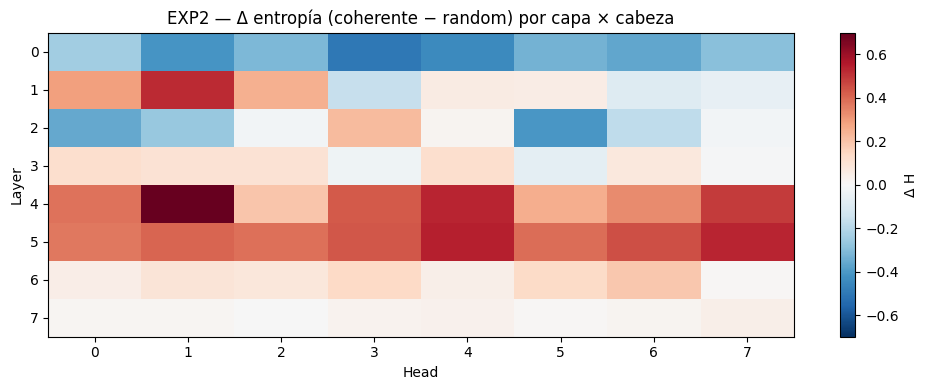

In [11]:
#  Heatmap Δ (sense − random)  
sense_stack = stack_metric(sense_metrics, "A_attn_entropy")
rand_stack  = stack_metric(rand_metrics,  "A_attn_entropy")

ms = np.nanmean(sense_stack, axis=0)
mr = np.nanmean(rand_stack,  axis=0)

fig = heatmap_delta(ms, mr,
                     title="EXP2 — Δ entropía (coherente − random) por capa × cabeza",
                     label="Δ H")
plt.savefig("resultados_analisis/exp2_heatmap_entropia.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
#  Top 10 cabezas más sensibles  
print("Top 10 cabezas más sensibles (A_attn_entropy): coherente vs random")
print(f"{'Layer':>6} {'Head':>5} {'|Δ|':>8} {'sense':>8} {'random':>8}")
print("-" * 42)
for li, hi, d, a, b in top_sensitive_heads(sense_metrics, rand_metrics,
                                             key="A_attn_entropy", topk=10):
    print(f"  L{li:02d}    H{hi:02d}  {d:8.4f}  {a:8.4f}  {b:8.4f}")

Top 10 cabezas más sensibles (A_attn_entropy): coherente vs random
 Layer  Head      |Δ|    sense   random
------------------------------------------
  L04    H01    0.6984    1.5660    0.8677
  L05    H04    0.5409    1.8113    1.2704
  L04    H04    0.5338    1.3721    0.8383
  L05    H07    0.5329    1.9336    1.4007
  L01    H01    0.5219    0.8944    0.3726
  L00    H03    0.4971    1.4282    1.9254
  L04    H07    0.4861    1.5074    1.0213
  L05    H06    0.4522    1.9034    1.4513
  L00    H04    0.4448    1.3426    1.7874
  L05    H03    0.4320    1.8743    1.4422


## EXP3 — Diferenciación de estilo: wiki vs. poem

**Hipótesis**: el style embedding condiciona las cabezas de atención de forma
diferenciada. Algunas cabezas tendrán mayor entropía en modo poem (lenguaje más
libre y ambiguo) que en modo wiki (prosa factual más estructurada).


In [13]:
TEXTS_EXP3 = [
    "El agua cubre aproximadamente el setenta por ciento de la superficie terrestre.",
    "La ciudad de Toledo se encuentra situada en el centro de la península ibérica.",
    "Los árboles crecen absorbiendo dióxido de carbono y liberando oxígeno al ambiente.",
    "El tiempo meteorológico varía en función de la presión atmosférica y la temperatura.",
    "Los ríos transportan sedimentos desde las montañas hasta el mar a lo largo de su recorrido.",
    "El hierro es uno de los metales más abundantes en la corteza terrestre.",
    "Los pájaros construyen nidos para proteger sus huevos durante el periodo de incubación.",
    "La luna completa una órbita alrededor de la Tierra aproximadamente cada veintinueve días.",
    "El fuego necesita oxígeno, combustible y calor para mantenerse encendido.",
    "Los desiertos reciben menos de doscientos cincuenta milímetros de precipitación al año.",
    "El sonido viaja a mayor velocidad en sólidos que en gases debido a la densidad del medio.",
    "Las estaciones del año están causadas por la inclinación del eje de la Tierra respecto al Sol.",
    "El corazón humano bombea sangre a través del cuerpo mediante contracciones rítmicas.",
    "La sal se obtiene principalmente mediante la evaporación del agua del mar.",
    "Los peces respiran mediante branquias que extraen el oxígeno disuelto en el agua.",
    "Las nubes se forman cuando el vapor de agua se condensa alrededor de partículas en suspensión.",
    "El viento es el movimiento de masas de aire causado por diferencias de presión atmosférica.",
    "Los metales conducen la electricidad porque tienen electrones libres que pueden moverse fácilmente.",
    "El papel se fabrica a partir de fibras de celulosa obtenidas principalmente de la madera.",
    "Las mareas son provocadas por la atracción gravitacional de la Luna y el Sol sobre los océanos.",
]

set_seed(42)

wiki_metrics, poem_metrics = [], []
for t in TEXTS_EXP3:
    _, mw = capture_text(t, STYLE_WIKI, MAX_LEN)
    _, mp = capture_text(t, STYLE_POEM, MAX_LEN)
    wiki_metrics.append(mw)
    poem_metrics.append(mp)

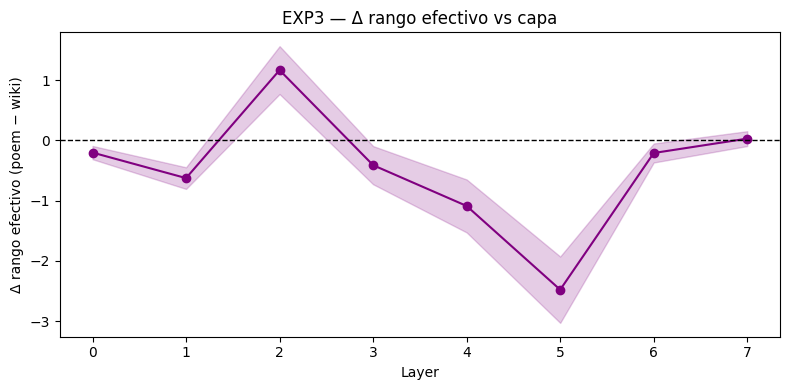

In [14]:
#  Δ rango efectivo vs capa  
wiki_er = stack_metric(wiki_metrics, "A_effective_rank")
poem_er = stack_metric(poem_metrics, "A_effective_rank")

ER_wiki = np.nanmean(wiki_er, axis=2)   # (N, L)
ER_poem = np.nanmean(poem_er, axis=2)

delta = ER_poem - ER_wiki
mu    = np.nanmean(delta, axis=0)       # (L,)
sd    = np.nanstd(delta,  axis=0)

layers = np.arange(len(mu))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(layers, mu, marker="o", color="purple")
ax.fill_between(layers, mu - sd, mu + sd, alpha=0.2, color="purple")
ax.axhline(0.0, linestyle="--", linewidth=1, color="black")
ax.set_xlabel("Layer"); ax.set_ylabel("Δ rango efectivo (poem − wiki)")
ax.set_title("EXP3 — Δ rango efectivo vs capa")
plt.tight_layout(); 
plt.savefig("resultados_analisis/exp3_rango_efectivo.png", dpi=120, bbox_inches="tight")
plt.show()

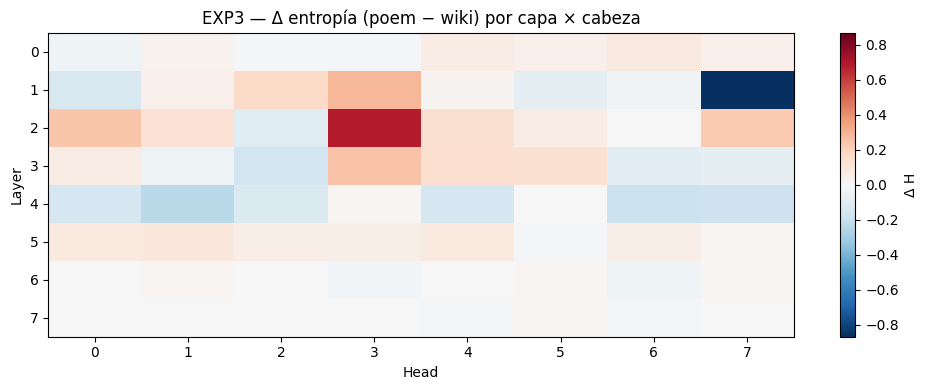

In [15]:
#  Heatmap Δ entropía (poem − wiki) 
wiki_stack = stack_metric(wiki_metrics, "A_attn_entropy")
poem_stack = stack_metric(poem_metrics, "A_attn_entropy")

mw = np.nanmean(wiki_stack, axis=0)
mp = np.nanmean(poem_stack, axis=0)

fig = heatmap_delta(mp, mw,
                     title="EXP3 — Δ entropía (poem − wiki) por capa × cabeza",
                     label="Δ H")
plt.savefig("resultados_analisis/exp3_heatmap_entropia.png", dpi=120, bbox_inches="tight")
plt.show()

In [16]:
#  Top 10 cabezas más diferenciadas (wiki vs poem) 
print("Top 10 cabezas wiki vs poem (A_attn_entropy):")
print(f"{'Layer':>6} {'Head':>5} {'|Δ|':>8} {'wiki':>8} {'poem':>8}")
print("-" * 42)
for li, hi, d, aw, ap in top_sensitive_heads(wiki_metrics, poem_metrics,
                                               key="A_attn_entropy", topk=10):
    print(f"  L{li:02d}    H{hi:02d}  {d:8.4f}  {aw:8.4f}  {ap:8.4f}")

Top 10 cabezas wiki vs poem (A_attn_entropy):
 Layer  Head      |Δ|     wiki     poem
------------------------------------------
  L01    H07    0.8673    1.6238    0.7565
  L02    H03    0.6785    0.7881    1.4666
  L01    H03    0.2901    1.2452    1.5353
  L03    H03    0.2472    0.9200    1.1672
  L02    H00    0.2431    1.2853    1.5284
  L04    H01    0.2331    1.4348    1.2017
  L02    H07    0.2304    1.1532    1.3836
  L04    H06    0.1895    0.9745    0.7850
  L04    H07    0.1788    1.3780    1.1992
  L01    H02    0.1671    1.0283    1.1954


## 4. Guardado de resultados

In [17]:
from pathlib import Path
RESULTS_DIR = Path("resultados_analisis")
RESULTS_DIR.mkdir(exist_ok=True)

# Guardar una captura de ejemplo
run_example, metrics_example = capture_text(
    "El lenguaje crea mundos: nombra lo ausente.", STYLE_WIKI
)
save_run(run_example,       RESULTS_DIR / "example_run.npz")

save_metrics(metrics_example, RESULTS_DIR / "example_metrics.json")

# Verificar round-trip
run2 = load_run(RESULTS_DIR / "example_run.npz")
print(f"Round-trip OK: {run2.n_layers} capas, seq_len={run2.seq_len}")
print(f"Ficheros guardados en {RESULTS_DIR.resolve()}")

Round-trip OK: 8 capas, seq_len=12
Ficheros guardados en C:\Users\Carolina\Desktop\uni\quinto\tfg\INSO\paquete\INSO_TFG\experiments\notebooks\resultados_analisis
